Saving RANDOM PIC.jpg to RANDOM PIC.jpg


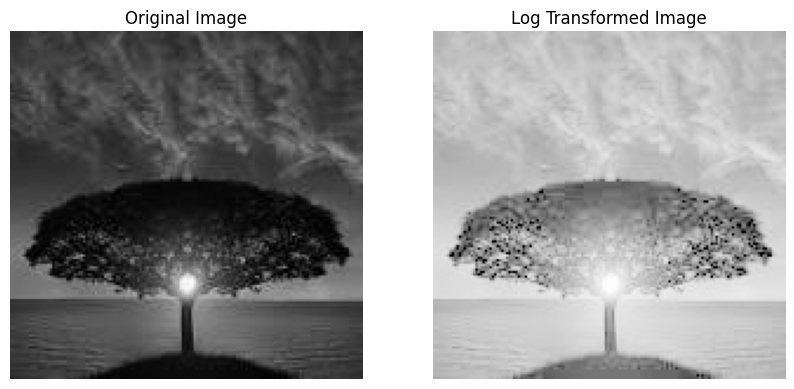

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload image
uploaded = files.upload()

# Get uploaded file name
filename = list(uploaded.keys())[0]

# Read image
img = cv2.imread(filename, 0)

# Check whether image was loaded
if img is None:
    print("Error: Image could not be loaded.")
else:
    # c = 1
    c = 1

    # Log transformation
    log_image = c * np.log1p(img.astype(np.float32))

    # Normalize to 0-255
    log_image = cv2.normalize(
        log_image, None, 0, 255, cv2.NORM_MINMAX
    )

    # Convert to uint8
    log_image = np.uint8(log_image)

    # Display original image
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap="gray")
    plt.title("Original Image")
    plt.axis("off")

    # Display log transformed image
    plt.subplot(1, 2, 2)
    plt.imshow(log_image, cmap="gray")
    plt.title("Log Transformed Image")
    plt.axis("off")

    plt.show()

Saving RANDOM PIC.jpg to RANDOM PIC (1).jpg
Enter the value of gamma: 120


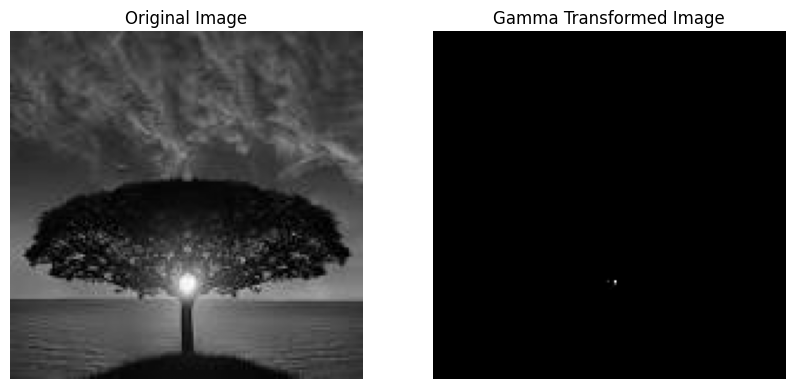

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload image
uploaded = files.upload()

# Get image filename
filename = list(uploaded.keys())[0]

# Read image in grayscale
img = cv2.imread(filename, 0)

# Check image
if img is None:
    print("Error: Image could not be loaded.")
else:
    # Take gamma value from user
    gamma = float(input("Enter the value of gamma: "))

    # Assume c = 1
    c = 1

    # Normalize image from 0-255 to 0-1
    normalized = img / 255.0

    # Power law / Gamma transformation
    gamma_image = c * (normalized ** gamma)

    # Convert back to 0-255
    gamma_image = np.uint8(gamma_image * 255)

    # Display images
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap="gray")
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(gamma_image, cmap="gray")
    plt.title("Gamma Transformed Image")
    plt.axis("off")

    plt.show()

Saving RANDOM PIC.jpg to RANDOM PIC (2).jpg
Enter input range lower value: 4
Enter input range upper value: 100
Enter output range lower value: 10
Enter output range upper value: 256


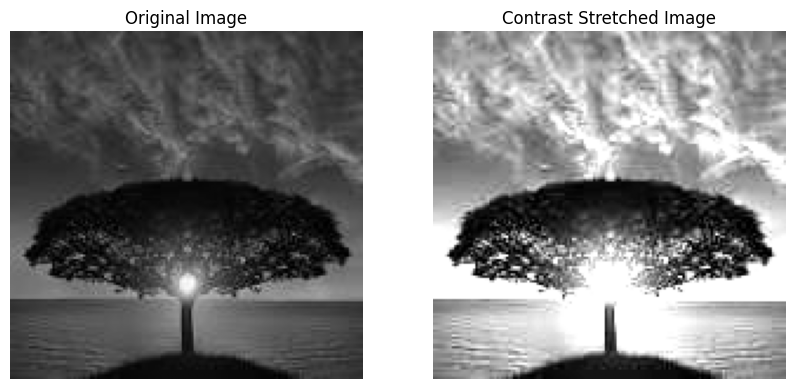

Saving RANDOM PIC.jpg to RANDOM PIC (3).jpg
Enter input range lower value: 80
Enter input range upper value: 150
Enter output range lower value: 120
Enter output range upper value: 150


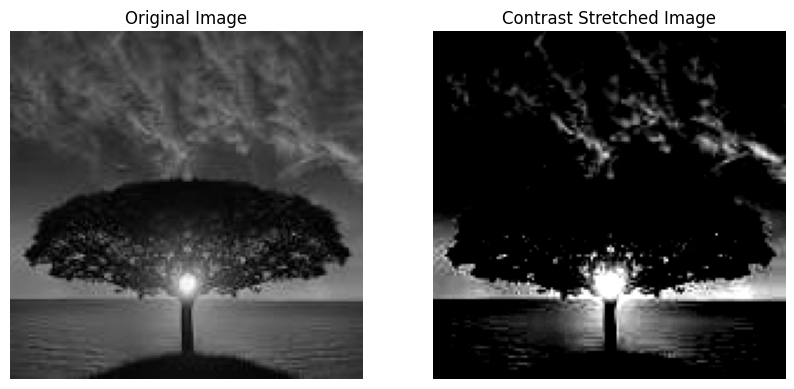

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload image
uploaded = files.upload()

# Get image filename
filename = list(uploaded.keys())[0]

# Read image in grayscale
img = cv2.imread(filename, 0)

# Check image
if img is None:
    print("Error: Image could not be loaded.")
else:
    # Input intensity range
    r1 = int(input("Enter input range lower value: "))
    r2 = int(input("Enter input range upper value: "))

    # Desired output intensity range
    s1 = int(input("Enter output range lower value: "))
    s2 = int(input("Enter output range upper value: "))

    # Create output image
    output = np.zeros_like(img, dtype=np.float32)

    # Pixels below input range
    output[img < r1] = s1

    # Pixels within input range
    mask = (img >= r1) & (img <= r2)

    # Contrast stretching formula
    output[mask] = s1 + (
        ((img[mask] - r1) / (r2 - r1)) * (s2 - s1)
    )

    # Pixels above input range
    output[img > r2] = s2

    # Keep values between 0 and 255
    output = np.clip(output, 0, 255)

    # Convert to uint8
    output = np.uint8(output)

    # Display images
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap="gray")
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(output, cmap="gray")
    plt.title("Contrast Stretched Image")
    plt.axis("off")

    plt.show()